<a href="https://colab.research.google.com/github/megluc/waymo-project/blob/main/VGG_implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import pandas as pd
import matplotlib.pyplot as plt
!pip install kagglehub
import kagglehub


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


In [3]:
# download the dataset
path = kagglehub.dataset_download("marquis03/bdd100k-scenario-classification")
print("Dataset path:", path)

Dataset path: /Users/eniyamadden/.cache/kagglehub/datasets/marquis03/bdd100k-scenario-classification/versions/1


In [4]:
import os
import hashlib
import pandas as pd

def get_file_hash(filepath, chunk_size=8192):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def collect_image_paths(root_dir):
    rows = []
    class_names = sorted(os.listdir(root_dir))
    
    for label_name in class_names:
        class_dir = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_dir):
            continue
            
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            if os.path.isfile(fpath):
                rows.append({
                    "filepath": fpath,
                    "label": label_name,
                    "filename": fname
                })
    return pd.DataFrame(rows)

train_df = collect_image_paths(os.path.join(path, "train"))
train_df["md5"] = train_df["filepath"].apply(get_file_hash)

dup_exact = train_df[train_df.duplicated("md5", keep=False)].sort_values("md5")
print("Number of exact duplicate files:", dup_exact.shape[0])
print(dup_exact.head(20))


#The exact same dataset was found in 2 lables

Number of exact duplicate files: 2
                                                filepath        label  \
39991  /Users/eniyamadden/.cache/kagglehub/datasets/m...  city street   
47793  /Users/eniyamadden/.cache/kagglehub/datasets/m...      highway   

                    filename                               md5  
39991  6e09762a-bab508de.jpg  2610db2b184b4ff1e22349a81ceb2571  
47793  559b242e-90cd7279.jpg  2610db2b184b4ff1e22349a81ceb2571  


In [9]:
# loading and splitting the dataset

img_size = (160, 160)
batch_size = 32

# Training set (70%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Validation set (30%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Test set (separate folder)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "val"),
    image_size=img_size,
    batch_size=batch_size
)

Found 69863 files belonging to 7 classes.
Using 48905 files for training.
Found 69863 files belonging to 7 classes.
Using 20958 files for validation.
Found 10000 files belonging to 7 classes.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(200).prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [24]:

def build_vgg(input_shape=(160, 160, 3), num_classes=7):
    l2 = tf.keras.regularizers.l2(1e-4)

    model = models.Sequential([

        # Explicit input layer to define input shape
        layers.Input(shape=input_shape),

        # Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),        

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=l2)
    ])
    return model
    
    
model = build_vgg(input_shape=(160, 160, 3), num_classes=7)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           51

 Total params: 1,192,999 (4.55 MB)

 Trainable params: 1,191,079 (4.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [25]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Epoch 1/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1180s 771ms/step - accuracy: 0.6495 - loss: 1.0076 - val_accuracy: 0.6376 - val_loss: 1.3040
Epoch 2/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1181s 772ms/step - accuracy: 0.6769 - loss: 0.9123 - val_accuracy: 0.6651 - val_loss: 1.0762
Epoch 3/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1483s 970ms/step - accuracy: 0.6947 - loss: 0.8716 - val_accuracy: 0.6638 - val_loss: 0.9785
Epoch 4/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1872s 1s/step - accuracy: 0.6995 - loss: 0.8451 - val_accuracy: 0.6922 - val_loss: 0.8760
Epoch 5/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 3375s 2s/step - accuracy: 0.7062 - loss: 0.8228 - val_accuracy: 0.6470 - val_loss: 1.1709
Epoch 6/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1528s 1000ms/step - accuracy: 0.7113 - loss: 0.8075 - val_accuracy: 0.7048 - val_loss: 0.8380
Epoch 7/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 3524s 2s/step - accuracy: 0.7150 - loss: 0.7887 - val_accuracy: 0.6931 - val_loss: 0.9147
Epoch 8/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 1289s 843ms/step - ac

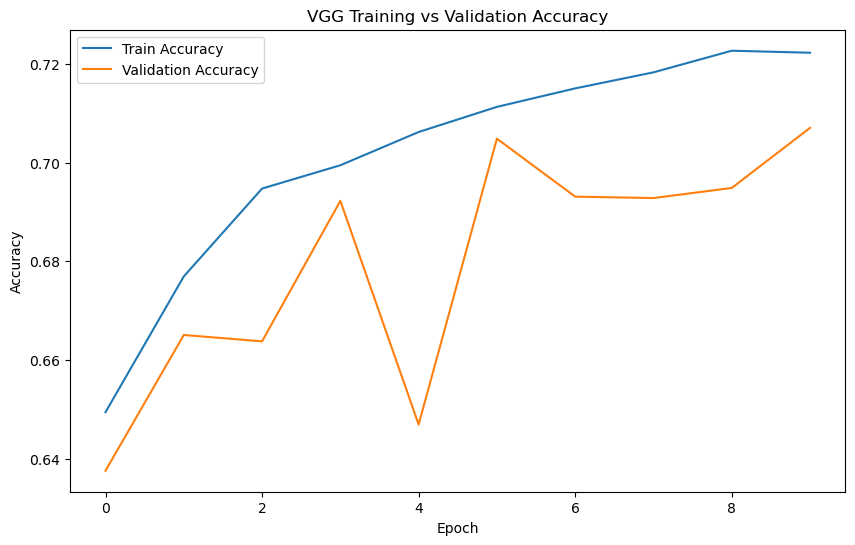

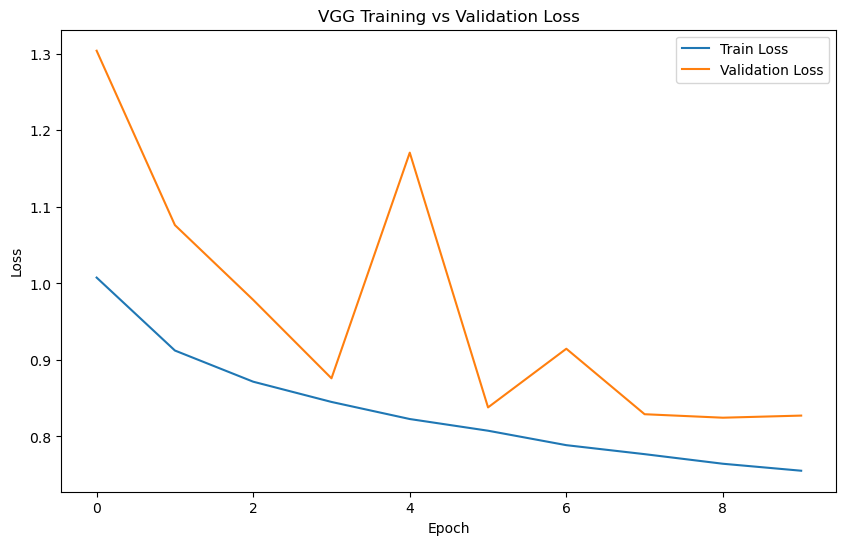

In [26]:
# plot accuracy and loss
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Accuracy plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG Training vs Validation Loss')
plt.legend()
plt.show()


In [27]:
test_loss, test_acc = model.evaluate(test_dataset)
print("VGG Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 161ms/step - accuracy: 0.6981 - loss: 0.8558
VGG Test Accuracy: 0.6980999708175659
